# Learning python 

## How do you use python?

Writing in python can be accessed from a multitude of locations. Three major locations are:
- Terminal for an interactive terminal session for quick commands
- Jupyter notebook, where code entered and quickly visualized
- Running `.py` scripts, which allows for greater and better use of computational resources

### Using terminal

On most systems, including VSCode on Biowulf, you can access python via terminal simply by typing `python`. A prompt will appear with three arrows `>>>` where python code will be entered. There is memory of the previous lines in this kind of an interactive session, but that memory does not carry between sessions. Any data that needs to be saved must be written out to a file. Additionally, figures can not be displayed unless saved, limiting interactivity. 

TL;DR using Python in terminal is good for quick tests and calculations.

### Using Jupyter notebooks

Juptyer notebooks are more interactive methods of saving both what you wrote and the output that can be saved as a .html, markdown, or pdf file. Notebooks are broken into a series of cells with one or many lines of code than remember the previous cell. As well, when you plot a figure in Jupyter the cell below shows that plot (which you will see because this page is actually a Juptyer notebook). 

Adding to its use, Jupyter notebooks can also run:
- Julia (**Ju**pyter)
- Terminal (Jupy**te**r)
- R (Jupyte**r**)
- Markdown (how this cell is being written)

I recommend trying new methods and performing data analysis in Juptyer notebooks, but don't save them for external use.

### Writing python scripts

Once you get a certain methodology working in your Jupyter notebooks, save that code into a more efficient Python `.py` script. While Jupyter notebooks are fun, they don't handle resources efficently or can be easily run in parallel. A good Python script can easily take an input file, perform some calculation, and give a result. I prefer to break steps down into manageable small scripts and string them together with [snakemake](snakemake.md). In addition, python scripts can be used in [singularity containers](singularity_page.md) to give reproducible outputs.

TL;DR use Python scripts for resource intensive, reproducible, repetitious tasks.

## What can python do?

### Variables and functions

No matter what language you are working with, you need to be able to see your output. Most of the output will be in the form of ASCII characters, unless you are producing an output of figures or graphs (which will still have underlying ASCII characters that are interpreted as an image). This is why its important to know how you output a set of characters, traditionally by saying `Hello World!`. This is done using the python `print` command.

In [1]:
print('Hello world!')

Hello world!


When you run Juptyer notebook for the first time, it will ask for a Python kernel to use. Use the one we made in the [Anaconda](anaconda.md) section as it has packages installed that will be necessary in this section.

`print` is actually a function, built-in to python and available in Python 3. There are many functions built into Python, which 


In Python 2 `print` is statement, but unless necessary we will use Python 3 going forward.  

Python also can create arrays of data, either in lists [], tuples (), dictionaries {}, or sets {}. For brevity, we will stick to lists

In [2]:
a = [1, 2, 3]

Once the variable `a` has been assigned the value of the following list, we can execute the cell just with the variable `a` to return the result:

In [3]:
a

[1, 2, 3]

Let's define a second list

In [4]:
b = [2, 3, 4]
b

[2, 3, 4]

Lists can be appended to one another. When we add `b` to `a`, defining `c`, we get the concatenation of `b` and `a` (order matters).

In [6]:
c = a + b
c

[1, 2, 3, 2, 3, 4]

For any variable, if we don't know what kind it is, we can use the function `type` to return the name of the type of variable.

In [5]:
type(a)

list

If the value in a list is needed, we can **slice** out that value using brackets. 

**Important**: Python is 0-indexed, meaning the first item in a list is the 0th item, the second item is the 1st item, and so on.

In [6]:
a[1]

2

### Manipulating strings

As bioinformatics deals with a lot of nucleotides as characters, manipulating string-type variables is quite useful.

In [7]:
first_sentence = 'Hello world!'

As we can see it is of the type `str`.

In [8]:
type(first_sentence)

str

Sometimes it is useful to convert numerical values to strings. We can assign the variable `d` the value of `4`.

In [9]:
d = 4
type(d)

int

`str` operates as function, turning the value within to the type `str`.

In [10]:
e = str(d)
type(e)

str

We can add strings together, just as we did with lists. Let's define `new_word` as the string `Again!`.

In [11]:
new_word = 'Again!'

Adding the two strings together gives a new string.

In [12]:
second_sentence = first_sentence + new_word
second_sentence

'Hello world!Again!'

In addition to adding strings together, we can also slice out characters or words as we would with a list. To get the first two letters of the string `new_word`:

In [13]:
new_word_slice = new_word[0:2]
new_word_slice

'Ag'

Appending and slicing strings becomes very important for `.fasta` parsing.

### Loops

It is often useful to loop through items of a list (or a string). We do this by saying `for` an element in some `list`. To return a simple list of integers we can use the `range` function:

In [14]:
for i in range(3):
    print(i)

0
1
2


Looping through a list looks like:

In [15]:
for number in a:
    print(number)

1
2
3


If we wanted to loop for an indefinite amount of time, we can use a `while` loop, which will go on forever until some condition is met.

In [16]:
stop = 0
while stop < 5:
    # Add one value to stop
    stop += 1
    print(stop)

1
2
3
4
5


## A bioinformatic example

Using these fundamentals, let's apply Python to a biological question. 

Suppose we wanted a list of every possible codon sequence (just in DNA).

First we would define what is a nucleotide, the subunit of a codon.

In [17]:
# Define nucleotides
nucs = ['A', 'T', 'C', 'G']

Next we loop through all possible nucleotides at all three positions.

In [18]:
for first_nuc in nucs:
    for second_nuc in nucs:
        for third_nuc in nucs:
            print(first_nuc + second_nuc + third_nuc)

AAA
AAT
AAC
AAG
ATA
ATT
ATC
ATG
ACA
ACT
ACC
ACG
AGA
AGT
AGC
AGG
TAA
TAT
TAC
TAG
TTA
TTT
TTC
TTG
TCA
TCT
TCC
TCG
TGA
TGT
TGC
TGG
CAA
CAT
CAC
CAG
CTA
CTT
CTC
CTG
CCA
CCT
CCC
CCG
CGA
CGT
CGC
CGG
GAA
GAT
GAC
GAG
GTA
GTT
GTC
GTG
GCA
GCT
GCC
GCG
GGA
GGT
GGC
GGG


Printing out the result isn't always the most useful. Suppose we want to save the codons in a list. If we want to save the codon strings for later, we need to save the string to to a list with the `append` **method**. 

**Methods** are a way of saying what actions a variable can do, and similarly **attributes** are what defines a variable. Together they allow for variables to interact with other variables.

In [19]:
# Define the empty list
codon_list = []

# Loop through and add new codons to the list
for first_nuc in nucs:
    for second_nuc in nucs:
        for third_nuc in nucs:
            codon_list.append(first_nuc + second_nuc + third_nuc)

If you don't want to take time and space rewriting code, **functions** allow for taking in one, some, or none variables and returning some other variables. For our codon table example:

In [20]:
def give_codon_table():
    codon_list = []
    for first_nuc in nucs:
        for second_nuc in nucs:
            for third_nuc in nucs:
                codon_list.append(f'{first_nuc}{second_nuc}{third_nuc}')
    return codon_list

Now we can get a list of codons just by calling `give_codon_table`. The output can be assigned to a new variable `codon_table`. 

As this list is pretty long, to save space we can ask how many elements are in a variable with the `len` function, and we can inspect the first five items by slicing.

In [21]:
codon_table = give_codon_table()
len(codon_table), codon_table[:5]

(64, ['AAA', 'AAT', 'AAC', 'AAG', 'ATA'])

### Using modules

From a biology perspective, we know that the codons for the 0th and 3rd codons are different, but they both code for the same amino acid Lysine. In python we can define two variable are the same by using the **operator** `==` (like `+`, `-`, `=`, `<`, `>`), returning if it is the boolean value `True` or `False`.

In [27]:
codon_list[0]

'AAA'

In [28]:
codon_list[3]

'AAG'

Knowing these two strings are different, we see that comparing them results in `False`.

In [29]:
codon_list[0] == codon_list[3]

False

While we could go through the trouble of building a table of codon to amino acid values, we are not the first people to think of this.

One of the greatest strengths in Python is the large number of packages and modules that can answer questions we have. This becomes a problem if your desire is to write code no one else has done before, but that is outside the scope of this lesson.

[`Biopython`](https://biopython.org/) is an amazing package with a lot of the fundamental tools for handling bioinformatic data. It isn't great for everything, but it has good fundamentals. In the previous [Anaconda](anaconda.md) section we made an environment that had Biopython installed, now we can load it with:

In [22]:
from Bio import Seq

The `Seq` module in the `Bio` (Biopython) package is really a **class** object that can have **methods** applied to it. For more information type `help(Seq)`.

We can define `codon_1` as a `Seq` object with the property of it's `Seq` being the 0th string in the codon list.

In [23]:
codon_1 = Seq.Seq(codon_list[0])
type(codon_1), codon_1

(Bio.Seq.Seq, Seq('AAA'))

The codon object can be translated into it's amino acid using the `.translate()` method.

In [ ]:
amino_acid_1 = codon_1.translate()

Resulting in objects `codon_1` and `amino_acid_1`.

In [41]:
str(codon_1), str(amino_acid_1)

('AAA', 'K')

This can be done again with the 3rd codon.

In [42]:
codon_2 = Seq.Seq(codon_list[3])
amino_acid_2 = codon_2.translate()
str(codon_2), str(amino_acid_2)

('AAG', 'K')

Again we confirm the codons are different.

In [43]:
str(codon_1) == str(codon_2)

False

But we see that the amino acids are the same!

In [44]:
str(amino_acid_1) == str(amino_acid_2)

True

One can imagine this can be applied at a higher level for translating great unknown sequences from metagenomic data, or calculating dN/dS ratios from Coronavirus populations. These packages may already be out there. But use these tools to play with data and ideas and who knows what you will discover!

### I/O 

While the function we have made for creating amino acids is useful and quick, it does not exist outside of this notebook. To save this data we can use the `write` method after opening a new file with the `open` function.

In [24]:
# Open a new file to write to with the 'w' flag
with open('../data/codon_list.txt', 'w') as f:
    # Loop through codons
    for codon in codon_list:
        # Write the codon
        f.write(codon)
        f.write('\n')
    # Always good to close files to prevent memory leaks
    f.close()

We can use the `open` function with the read `r` flag to now open the file.

In [25]:
# Let's open that file up

# Define new list to store data
new_codon_list = []
with open('../data/codon_list.txt', 'r') as f:
    for line in f.readlines():
        new_codon_list.append(line)
    f.close()
new_codon_list[:5]

['AAA\n', 'AAT\n', 'AAC\n', 'AAG\n', 'ATA\n']

However the `newline` character is read in as well, even if we don't see it in the file. We can remove it with the `strip` method.

In [26]:
# Let's open that file up, with removed 

# Define new list to store data
new_codon_list = []
with open('../data/codon_list.txt', 'r') as f:
    for line in f.readlines():
        line = line.strip()
        new_codon_list.append(line)
    f.close()
new_codon_list[:5]

['AAA', 'AAT', 'AAC', 'AAG', 'ATA']

## Scientific computation

A cornerstone of bioinformatics is quantitative analysis. `Numpy`, amongst `Scipy`, `Sklearn`, `Matplotlib`, `Seaborn`, and `Pandas`, serves as the bedrock for efficent, reproducible code.

In [27]:
import numpy as np

Remember we defined our first variable `a`, a list.

In [28]:
a

[1, 2, 3]

`Numpy` arrays are like lists, but with linear algebra capability. Lists can be converted to arrays:

In [29]:
a_np = np.array(a)
a_np

array([1, 2, 3])

With a list if we multiple it 3 times, we make 3 copies.

In [48]:
a * 3

[1, 2, 3, 1, 2, 3, 1, 2, 3]

With an array if we multiple it 3 times, we multiple each value by 3.

In [49]:
a_np * 3

array([3, 6, 9])

A much deeper dive into the full linear algebra capabilities is out of the scope of this lesson, but truly it is one of the best methods for performing these computations.

### Randomness

Of the many modules in `Numpy` is it's random number generator. Endless mathematicians have been fascinated by randomness, and it plays an important part in biology as well. 

With the `random` module we can get a random number between 0 and 1 easily:

In [30]:
np.random.random()

0.308979932712822

For that matter we can get 5!

In [31]:
np.random.random(5)

array([0.87015478, 0.5240611 , 0.43159515, 0.8005946 , 0.41942209])

We can also sample a bionomial distribution.

Suppose we wanted to simulate flipping a fair (50%) coin (don't dive too deep into what is a [fair coin](https://arxiv.org/abs/2310.04153)). We can use the `binomial` function 100 times for a value of 1 (heads) or 0 (tails).

In [33]:
fair_coin = np.random.binomial(n=1, p=.5, size=100)
fair_coin

array([0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0])

We can easily get the number of heads by getting a sum of the 1s, and subtracting from the total number of flips.

In [34]:
heads_count = sum(fair_coin)
tails_count = 100 - sum(fair_coin)
heads_count, tails_count

(np.int64(62), np.int64(38))

This is nice, but there is a limit of how many lists and tables we would want to present. `Matplotlib` is a wonderful and endlessly customizable package for plotting data.

In [35]:
import matplotlib.pyplot as plt

Using the function `bar` to create a barplot.

<BarContainer object of 2 artists>

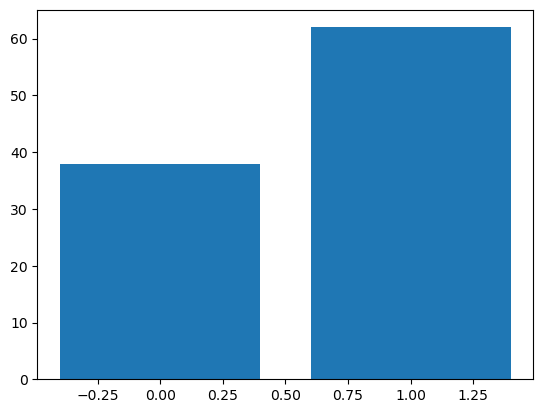

In [36]:
plt.bar([0, 1], [tails_count, heads_count])

Again that is nice, but not a figure we would see in Nature. Let's add some fun color, label our axes, and give a title.

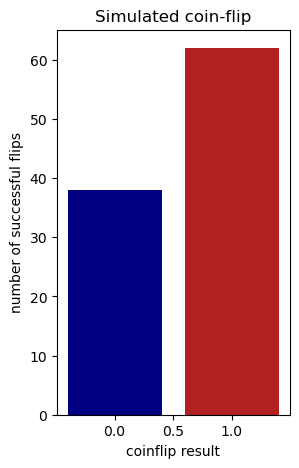

In [37]:
plt.figure(figsize=(3, 5))
plt.bar(x = [0, 1], height = [tails_count, heads_count], label=['tails', 'heads'], color=['navy', 'firebrick'])
plt.ylabel('number of successful flips')
plt.xlabel('coinflip result')
plt.title('Simulated coin-flip')
plt.savefig('coin_flip_figure.png')

That looks better!

## Pandas-seaborn

Suppose we want to simulate a fair (50% heads) and unfair (75% heads) coins. We can make a second list of unfair coins and compare.

In [38]:
fair_coin

array([0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0])

In [39]:
unfair_coin = np.random.binomial(n=1, p=.75, size=100)
unfair_coin

array([1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Keeping track of two separate data sets is hard, let's use the principle of tidy data and `Pandas` to combine the data into a readable DataFrame.

In [40]:
import pandas as pd

We can convert the numpy arrays into a DataFrame with each flip annotated.

In [44]:
fair_coin_df = pd.DataFrame(
    {
        'observation': fair_coin, 
        'fair': 'fair'
        }
    )
fair_coin_df.head()

,observation,fair
0,0,fair
1,1,fair
2,0,fair
3,1,fair
4,0,fair


And again to the unfair coin DataFrame

In [47]:
unfair_coin_df = pd.DataFrame(
    {
        'observation': unfair_coin, 
        'fair': 'unfair'
        }
    )
unfair_coin_df.head()

,observation,fair
0,1,unfair
1,0,unfair
2,1,unfair
3,1,unfair
4,1,unfair


If the columns are the same, DataFrames can be concatenated (just make sure the metadata is there!)

In [49]:
coin_df = pd.concat([fair_coin_df, unfair_coin_df])

The `.info()` method retuns the information about the DataFrame.

In [51]:
coin_df.info()

<class 'pandas.DataFrame'>
Index: 200 entries, 0 to 99
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   observation  200 non-null    int64
 1   fair         200 non-null    str  
dtypes: int64(1), str(1)
memory usage: 4.7 KB


Just like arrays, lists, and strings, we can slice out which values we want.

In [54]:
coin_df[coin_df['fair'] == 'fair'].head()

,observation,fair
0,0,fair
1,1,fair
2,0,fair
3,1,fair
4,0,fair


Or get summary values quickly.

In [61]:
coin_df.groupby(['observation', 'fair']).sum()

Empty DataFrame
Columns: []
Index: [(0, fair), (0, unfair), (1, fair), (1, unfair)]

`Pandas` works well with the package `Seaborn`, which creates beautiful figures easily.

In [63]:
import seaborn as sns

In [74]:
outcome_dict = {1: 'heads', 0: 'tails'}
coin_df['outcome'] = [outcome_dict[x] for x in coin_df['observation']]
coin_df.head()

,observation,fair,outcome
0,0,fair,tails
1,1,fair,heads
2,0,fair,tails
3,1,fair,heads
4,0,fair,tails


In [82]:
coin_df.groupby(['outcome', 'fair']).count().reset_index()

,outcome,fair,observation
0,heads,fair,62
1,heads,unfair,76
2,tails,fair,38
3,tails,unfair,24


Text(0.5, 1.0, 'Outcome of randomly flipping two coins')

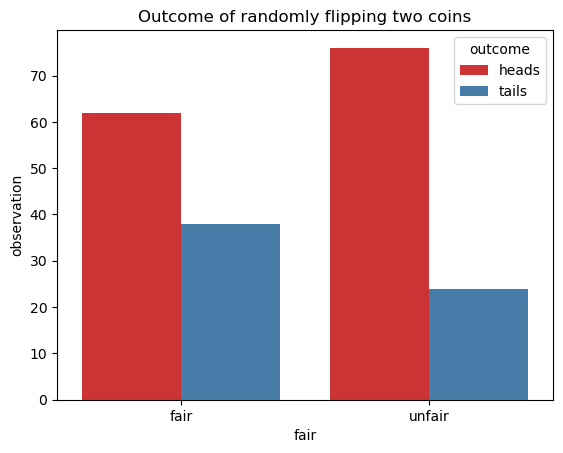

In [84]:
sns.barplot(
    data = coin_df.groupby(['outcome', 'fair']).count().reset_index(),
    y = 'observation',
    hue = 'outcome',
    x = 'fair',
    palette = 'Set1'
)
plt.title('Outcome of randomly flipping two coins')

And we can easily save and read our data in .csv format easily and quickly.

In [71]:
coin_df.to_csv('../data/coin_data.csv', sep=',', index=False)

In [72]:
coin_df = pd.read_csv('../data/coin_data.csv')
coin_df.head()

,observation,fair
0,0,fair
1,1,fair
2,0,fair
3,1,fair
4,0,fair
